In [1]:
import pandas as pd
import numpy as np

In [2]:
data = {
    "Hyperinsulinemic_obese": [2.3, 4.1, 4.2, 4.0, 4.6, 4.6, 3.8, 5.2, 3.1, 3.7, 3.8, np.nan],
    "Non_hyperinsulinemic_obese": [3.0, 4.1, 3.9, 3.1, 3.3, 2.9, 3.3, 3.9, np.nan, np.nan, np.nan, np.nan],
    "Controls": [3.0, 2.6, 3.1, 2.2, 2.1, 2.4, 2.8, 3.4, 2.9, 2.6, 3.1, 3.2],
}

df = pd.DataFrame(data)

In [3]:
df

,Hyperinsulinemic_obese,Non_hyperinsulinemic_obese,Controls
0,2.3,3.0,3.0
1,4.1,4.1,2.6
2,4.2,3.9,3.1
3,4.0,3.1,2.2
4,4.6,3.3,2.1
5,4.6,2.9,2.4
6,3.8,3.3,2.8
7,5.2,3.9,3.4
8,3.1,NaN,2.9
9,3.7,NaN,2.6


# (a)

In [4]:
df_long = (
    df
    .melt(var_name="group", value_name="outcome")
    .dropna()
    .reset_index(drop=True)
)

# --- ダミー変数化 (0/1フラグ) ---
df_long["Hyperinsulinemic_obese_flag"] = (df_long["group"] == "Hyperinsulinemic_obese").astype(int)
df_long["Non_hyperinsulinemic_obese_flag"] = (df_long["group"] == "Non_hyperinsulinemic_obese").astype(int)
df_long["Controls_flag"] = (df_long["group"] == "Controls").astype(int)

In [5]:
df_long

,group,outcome,Hyperinsulinemic_obese_flag,Non_hyperinsulinemic_obese_flag,Controls_flag
0,Hyperinsulinemic_obese,2.3,1,0,0
1,Hyperinsulinemic_obese,4.1,1,0,0
2,Hyperinsulinemic_obese,4.2,1,0,0
3,Hyperinsulinemic_obese,4.0,1,0,0
4,Hyperinsulinemic_obese,4.6,1,0,0
5,Hyperinsulinemic_obese,4.6,1,0,0
6,Hyperinsulinemic_obese,3.8,1,0,0
7,Hyperinsulinemic_obese,5.2,1,0,0
8,Hyperinsulinemic_obese,3.1,1,0,0
9,Hyperinsulinemic_obese,3.7,1,0,0


In [7]:
# 目的変数
y = df_long["outcome"].values

# 説明変数
X0 = np.column_stack([np.ones(len(y))])

# 係数
beta0 = np.linalg.inv(X0.T@X0) @ X0.T @ y

# 逸脱度
D0 = y.T @ y - beta0 @ X0.T @ y

# 自由度
dof0 = X0.shape[0] - X0.shape[1]

# 説明変数
X1 = df_long[["Hyperinsulinemic_obese_flag", "Non_hyperinsulinemic_obese_flag"]] # control群を端点制約の対象グループとした
X1 = np.column_stack([np.ones(len(X1)), X1])

# 係数
beta1 = np.linalg.inv(X1.T@X1) @ X1.T @ y

# 逸脱度
D1 = y.T @ y - beta1 @ X1.T @ y

# 自由度
dof1 = X1.shape[0] - X1.shape[1]

# F値
F = ((D0 - D1)/(dof0 - dof1)) / ((D1)/(dof1))

# 分散分析表
df_table = pd.DataFrame()
df_table.index = ["平均", "処理間", "残差", "合計"]
df_table["自由度"] = [1, dof0 - dof1, dof1, 1 + dof0]
df_table["平方和"] = [y.sum()**2 / len(y), D0 - D1, D1, y.sum()**2 / len(y) + D0]
df_table["平均平方"] = df_table["平方和"] / df_table["自由度"]
df_table["F値"] = [np.nan, F, np.nan, np.nan]
df_table.iloc[0, 2] = np.nan
df_table.iloc[3, 2] = np.nan

In [8]:
df_table.round(3)

,自由度,平方和,平均平方,F値
平均,1,350.919,NaN,NaN
処理間,2,7.808,3.904,11.651
残差,28,9.383,0.335,NaN
合計,31,368.110,NaN,NaN


## (b)

In [145]:
# 両群の平均の差
diff = df["Hyperinsulinemic_obese"].mean() - df["Non_hyperinsulinemic_obese"].mean()

# 各群のサンプルサイズ
n_hyp = df.dropna(subset = ["Hyperinsulinemic_obese"]).shape[0]
n_nonhyp = df.dropna(subset = ["Non_hyperinsulinemic_obese"]).shape[0]
n_control = df.dropna(subset = ["Controls"]).shape[0]

# 3群のプールされた分散
pooled_var= (
    (
        (n_hyp - 1) * df["Hyperinsulinemic_obese"].var() + 
        (n_nonhyp - 1) * df["Non_hyperinsulinemic_obese"].var() + 
        (n_control - 1) * df["Controls"].var()
    )
    / (n_hyp + n_nonhyp + n_control - 3)
)

# 標準偏差
std_deviance = np.sqrt(pooled_var)

# 95%信頼区間の上限と下限
lower_ci95 = diff - 2.048 * std_deviance * np.sqrt(( 1 / n_hyp + 1 / n_nonhyp ) )
upper_ci95 = diff + 2.048 * std_deviance * np.sqrt(( 1 / n_hyp + 1 / n_nonhyp ) )

In [147]:
lower_ci95

np.float64(-0.04291665853463977)

In [149]:
upper_ci95

np.float64(1.0588257494437303)

In [150]:
beta1

array([2.78333333, 1.16212121, 0.65416667])

In [184]:
# 残差
resid = y - X1 @ beta1

# 不偏分散
sigma_sq_hat = (resid ** 2).sum() / (X1.shape[0] - X1.shape[1])

# ハット行列
H = np.eye(X1.shape[0]) - X1@np.linalg.inv(X1.T@X1)@X1.T

# 標準化残差
r = resid / np.sqrt(sigma_sq_hat * (1 - np.diag(H)))
df_long["std_resid"] = r

In [185]:
df_long

,group,outcome,Hyperinsulinemic_obese_flag,Non_hyperinsulinemic_obese_flag,Controls_flag,std_resid
0,Hyperinsulinemic_obese,2.3,1,0,0,-9.427523
1,Hyperinsulinemic_obese,4.1,1,0,0,0.885458
2,Hyperinsulinemic_obese,4.2,1,0,0,1.458401
3,Hyperinsulinemic_obese,4.0,1,0,0,0.312515
4,Hyperinsulinemic_obese,4.6,1,0,0,3.750175
5,Hyperinsulinemic_obese,4.6,1,0,0,3.750175
6,Hyperinsulinemic_obese,3.8,1,0,0,-0.833372
7,Hyperinsulinemic_obese,5.2,1,0,0,7.187835
8,Hyperinsulinemic_obese,3.1,1,0,0,-4.843976
9,Hyperinsulinemic_obese,3.7,1,0,0,-1.406316


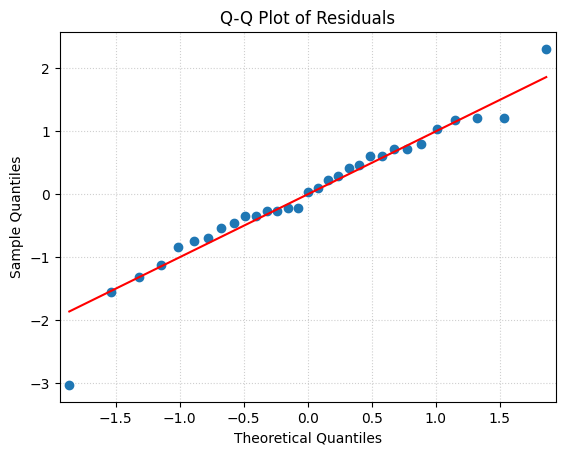

In [188]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
fig = sm.qqplot(df_long["std_resid"], line='s', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("QQplot.png")
plt.show()